In [595]:
import pandas as pd

In [596]:
import xarray

In [597]:
# 駿河湾の領域
#気象庁
#lat_min, lat_max = 34.3, 35.3
#lon_min, lon_max = 138.2, 138.8

#海保の領域(Area A)
#lat_min, lat_max = 34.5, 35.25
#lon_min, lon_max = 138.25, 138.75

#広め
#lat_min, lat_max = 33.0, 35.25
#lon_min, lon_max = 137.0, 138.75

#広域(Area B)
#lat_min, lat_max = 31.0, 35.25
#lon_min, lon_max = 135.75, 138.75

In [598]:
import os
import numpy as np
import pandas as pd
import netCDF4
from datetime import datetime, timedelta

# =========================
# 設定（ここだけ確認）
# =========================
#nc_dir = r"C:\Users\kimurakaisei\Desktop\新しいフォルダー\MGDSST"
nc_dir = "MGDSST"
#ybgn, yend = 1982, 2023
ybgn, yend = 1991, 2020
# ファイル名パターン
fname_pat = "mgdsst_jpn.{year}.nc"

# 駿河湾の領域
#lat_min, lat_max = 34.3, 35.2
#lon_min, lon_max = 138.2, 138.8

# 出力ファイル
out_txt = "MGDSST_suruga_mean.txt"

# 欠損値（あなたの作成コードに合わせる）
FILL = -9.99e33

# =========================
# メイン処理
# =========================
records = []

for year in range(ybgn, yend + 1):
    fname = os.path.join(nc_dir, fname_pat.format(year=year))
    if not os.path.exists(fname):
        raise FileNotFoundError(f"見つかりません: {fname}")

    print("reading:", fname)
    nc = netCDF4.Dataset(fname, "r")

    tos = nc.variables["tos"][:]   # (time, lat, lon)
    lat = nc.variables["lat"][:]   # (lat,)
    lon = nc.variables["lon"][:]   # (lon,)

    nc.close()

    # 領域インデックス
    lat_idx = np.where((lat >= lat_min) & (lat <= lat_max))[0]
    lon_idx = np.where((lon >= lon_min) & (lon <= lon_max))[0]

    if len(lat_idx) == 0 or len(lon_idx) == 0:
        raise ValueError("指定領域に該当する格子点がありません")

    # 欠損を NaN に
    tos = np.array(tos, dtype=float)
    tos[tos <= -9.99e32] = np.nan
    tos[tos == FILL] = np.nan

    # 領域平均（time ごと）
    sub = tos[:, lat_idx[:, None], lon_idx]
    mean_ts = np.nanmean(sub, axis=(1, 2))

    # 日付を作成（1月1日から順）
    for t, val in enumerate(mean_ts):
        date = datetime(year, 1, 1) + timedelta(days=int(t))
        records.append((date.year, date.month, date.day, val))

# =========================
# DataFrame化（area310.txt形式）
# =========================
df = pd.DataFrame(records, columns=["yyyy", "mm", "dd", "Temp."])

# Hobday法：2月29日を除外
df = df[~((df["mm"] == 2) & (df["dd"] == 29))].reset_index(drop=True)

# NaNを除外（念のため）
df = df.dropna(subset=["Temp."]).reset_index(drop=True)

# =========================
# 保存
# =========================
df.to_csv(out_txt, index=False, sep=",", float_format="%.2f")

print("保存完了:", out_txt)
print(df.head())
print("総日数:", len(df))

reading: MGDSST\mgdsst_jpn.1991.nc
reading: MGDSST\mgdsst_jpn.1992.nc
reading: MGDSST\mgdsst_jpn.1993.nc
reading: MGDSST\mgdsst_jpn.1994.nc
reading: MGDSST\mgdsst_jpn.1995.nc
reading: MGDSST\mgdsst_jpn.1996.nc
reading: MGDSST\mgdsst_jpn.1997.nc
reading: MGDSST\mgdsst_jpn.1998.nc
reading: MGDSST\mgdsst_jpn.1999.nc
reading: MGDSST\mgdsst_jpn.2000.nc
reading: MGDSST\mgdsst_jpn.2001.nc
reading: MGDSST\mgdsst_jpn.2002.nc
reading: MGDSST\mgdsst_jpn.2003.nc
reading: MGDSST\mgdsst_jpn.2004.nc
reading: MGDSST\mgdsst_jpn.2005.nc
reading: MGDSST\mgdsst_jpn.2006.nc
reading: MGDSST\mgdsst_jpn.2007.nc
reading: MGDSST\mgdsst_jpn.2008.nc
reading: MGDSST\mgdsst_jpn.2009.nc
reading: MGDSST\mgdsst_jpn.2010.nc
reading: MGDSST\mgdsst_jpn.2011.nc
reading: MGDSST\mgdsst_jpn.2012.nc
reading: MGDSST\mgdsst_jpn.2013.nc
reading: MGDSST\mgdsst_jpn.2014.nc
reading: MGDSST\mgdsst_jpn.2015.nc
reading: MGDSST\mgdsst_jpn.2016.nc
reading: MGDSST\mgdsst_jpn.2017.nc
reading: MGDSST\mgdsst_jpn.2018.nc
reading: MGDSST\mgds

In [599]:
df = pd.read_csv('area310.txt', skipfooter=1, engine='python') 

In [600]:
df

,yyyy,mm,dd,areaNo.,flag,Temp.
0,1982,1,1,310,R,16.89
1,1982,1,2,310,R,16.94
2,1982,1,3,310,R,16.96
3,1982,1,4,310,R,16.96
4,1982,1,5,310,R,16.95
...,...,...,...,...,...,...
16043,2025,12,4,310,P,19.30
16044,2025,12,5,310,P,18.98
16045,2025,12,6,310,P,18.71
16046,2025,12,7,310,P,18.53


In [601]:
df['Temp.']

0        16.89
1        16.94
2        16.96
3        16.96
4        16.95
         ...  
16043    19.30
16044    18.98
16045    18.71
16046    18.53
16047    18.42
Name: Temp., Length: 16048, dtype: float64

In [602]:
import matplotlib.pyplot as plt

In [603]:
df['date'] = pd.to_datetime(
    dict(year=df['yyyy'], month=df['mm'], day=df['dd']))

In [604]:
df

,yyyy,mm,dd,areaNo.,flag,Temp.,date
0,1982,1,1,310,R,16.89,1982-01-01
1,1982,1,2,310,R,16.94,1982-01-02
2,1982,1,3,310,R,16.96,1982-01-03
3,1982,1,4,310,R,16.96,1982-01-04
4,1982,1,5,310,R,16.95,1982-01-05
...,...,...,...,...,...,...,...
16043,2025,12,4,310,P,19.30,2025-12-04
16044,2025,12,5,310,P,18.98,2025-12-05
16045,2025,12,6,310,P,18.71,2025-12-06
16046,2025,12,7,310,P,18.53,2025-12-07


In [605]:
df.groupby('mm')['Temp.'].mean()

mm
1     16.465792
2     15.606693
3     15.966202
4     17.366955
5     19.580850
6     22.176765
7     25.100931
8     27.110689
9     26.129098
10    23.637060
11    21.189235
12    18.413736
Name: Temp., dtype: float64

In [606]:
df.groupby('mm')

In [607]:
x = df.groupby('mm')['mm'].mean()
y = df.groupby('mm')['Temp.'].mean()

In [608]:
df = pd.read_csv("MGDSST_suruga_mean.txt")

In [609]:
annual = df.groupby("yyyy")["Temp."].mean()

In [610]:
annual = annual.loc[1991:2020]

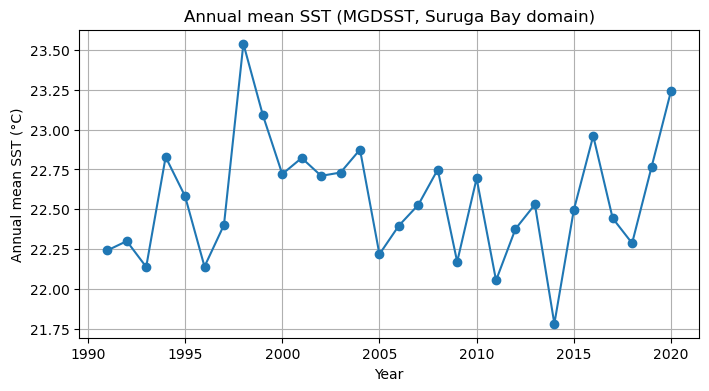

In [611]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(annual.index, annual.values, "-o")
plt.xlabel("Year")
plt.ylabel("Annual mean SST (°C)")
plt.title("Annual mean SST (MGDSST, Suruga Bay domain)")
plt.grid(True)
plt.show()

In [612]:
x = df.groupby('yyyy')['yyyy'].mean()
y = df.groupby('yyyy')['Temp.'].mean()

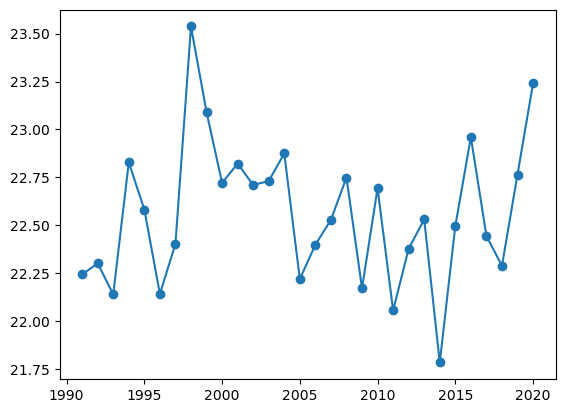

In [613]:
plt.figure()
plt.plot(x, y, '-o')
plt.show()

In [614]:
xa = x-x.mean()
ya = y-y.mean()

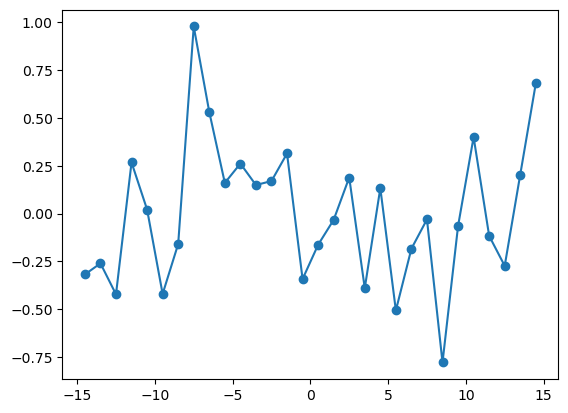

In [615]:
plt.figure()
plt.plot(xa, ya, '-o')
plt.show()

In [616]:
import numpy as np

In [617]:
a = np.linspace(0, 0.1, 101)

In [618]:
a

array([0.   , 0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008,
       0.009, 0.01 , 0.011, 0.012, 0.013, 0.014, 0.015, 0.016, 0.017,
       0.018, 0.019, 0.02 , 0.021, 0.022, 0.023, 0.024, 0.025, 0.026,
       0.027, 0.028, 0.029, 0.03 , 0.031, 0.032, 0.033, 0.034, 0.035,
       0.036, 0.037, 0.038, 0.039, 0.04 , 0.041, 0.042, 0.043, 0.044,
       0.045, 0.046, 0.047, 0.048, 0.049, 0.05 , 0.051, 0.052, 0.053,
       0.054, 0.055, 0.056, 0.057, 0.058, 0.059, 0.06 , 0.061, 0.062,
       0.063, 0.064, 0.065, 0.066, 0.067, 0.068, 0.069, 0.07 , 0.071,
       0.072, 0.073, 0.074, 0.075, 0.076, 0.077, 0.078, 0.079, 0.08 ,
       0.081, 0.082, 0.083, 0.084, 0.085, 0.086, 0.087, 0.088, 0.089,
       0.09 , 0.091, 0.092, 0.093, 0.094, 0.095, 0.096, 0.097, 0.098,
       0.099, 0.1  ])

In [619]:
a[n], np.sum((y-a[n]*x)**2)

(0.1, 950431.2028984524)

In [620]:
a = (x*y).mean()/(x*x).mean()

In [621]:
xa = x-x.mean()
ya = y-y.mean()

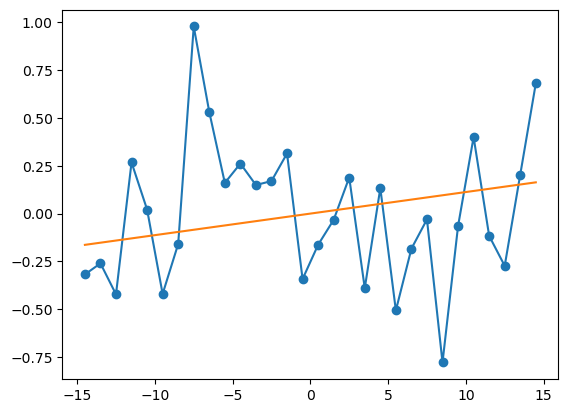

In [622]:
plt.figure()
plt.plot(xa, ya, '-o')
plt.plot(xa, a*xa)
plt.show()

In [623]:
a = (xa*ya).sum()/(xa*xa).sum()

In [624]:
a

0.0006873451475764988

In [625]:
df


,yyyy,mm,dd,Temp.
0,1991,1,1,18.99
1,1991,1,2,18.77
2,1991,1,3,18.60
3,1991,1,4,18.48
4,1991,1,5,18.40
...,...,...,...,...
10945,2020,12,27,20.85
10946,2020,12,28,20.71
10947,2020,12,29,20.60
10948,2020,12,30,20.51


In [626]:
baseline = df[(df['yyyy'] >= 1991) & (df['yyyy'] <= 2020)].copy()#基準期

In [627]:
df['date'] = pd.to_datetime(df[['yyyy', 'mm', 'dd']].rename(
    columns={'yyyy': 'year', 'mm': 'month', 'dd': 'day'}
))

baseline['date'] = pd.to_datetime(baseline[['yyyy', 'mm', 'dd']].rename(
    columns={'yyyy': 'year', 'mm': 'month', 'dd': 'day'}
))

In [628]:
#Day Of Year（その年の何日目か）
df['doy'] = df['date'].dt.dayofyear
baseline['doy'] = baseline['date'].dt.dayofyear

In [629]:
baseline[['date', 'doy', 'Temp.']].head()

,date,doy,Temp.
0,1991-01-01,1,18.99
1,1991-01-02,2,18.77
2,1991-01-03,3,18.60
3,1991-01-04,4,18.48
4,1991-01-05,5,18.40


In [630]:
doys = np.arange(1, 366)

clim_mean = np.zeros(len(doys))
clim_thresh = np.zeros(len(doys))

In [631]:
for i, d in enumerate(doys):
    window = baseline[
        (baseline['doy'] >= d-5) &
        (baseline['doy'] <= d+5)
    ]['Temp.']
    
    clim_mean[i] = window.mean()
    clim_thresh[i] = np.percentile(window, 90)

In [632]:
d = 100
window = baseline[
        (baseline['doy'] >= d-5) &
        (baseline['doy'] <= d+5)
    ]['Temp.']

In [633]:
window

94       18.77
95       18.93
96       19.06
97       19.27
98       19.45
         ...  
10684    19.66
10685    19.69
10686    19.71
10687    19.72
10688    19.72
Name: Temp., Length: 330, dtype: float64

In [634]:
clim = pd.DataFrame({
    'doy': doys,
    'climatology': clim_mean,
    'threshold': clim_thresh
})

In [635]:
clim.head()
clim.tail()

,doy,climatology,threshold
360,361,20.086948,20.890
361,362,20.059424,20.870
362,363,20.031613,20.853
363,364,20.004771,20.850
364,365,19.979255,20.850


In [636]:
# 解析対象（2025除外済み）を使う
target = df.copy()

# doy がまだ無ければ作る
target['doy'] = target['date'].dt.dayofyear

# doyごとの climatology・threshold を各日に付与する（結合）
df_mhw = target.merge(clim, on='doy', how='left')

In [637]:
# Hobday条件：その日の90%しきい値を超えたら True
df_mhw['is_hot'] = df_mhw['Temp.'] > df_mhw['threshold']

In [638]:
# True/False を 0/1 に
df_mhw['hot_int'] = df_mhw['is_hot'].astype(int)

# 連続区間のIDを作る（値が変わるたびに区切る）
df_mhw['grp'] = df_mhw['hot_int'].diff().ne(0).cumsum()

# True の区間だけイベント化
events = (
    df_mhw[df_mhw['is_hot']]
    .groupby('grp')
    .agg(
        start_date=('date', 'first'),
        end_date=('date', 'last'),
        duration=('date', 'count'),
        max_temp=('Temp.', 'max'),
        mean_temp=('Temp.', 'mean'),
        max_intensity=('Temp.', lambda s: (s - df_mhw.loc[s.index, 'climatology']).max()),
        mean_intensity=('Temp.', lambda s: (s - df_mhw.loc[s.index, 'climatology']).mean()),
    )
    .reset_index(drop=True)
)

# 5日以上連続（MHW）
#events_5days = events[events['duration'] >= 5].copy()
events_5days = events[events['duration'] >= 1].copy()

In [639]:
years = np.arange(1991, 2021)

mhwdays = (
    mhw_days_per_year
    .reindex(years)      # 年配列に合わせる
    .fillna(0)           # 無い年は 0
    .to_numpy()
)

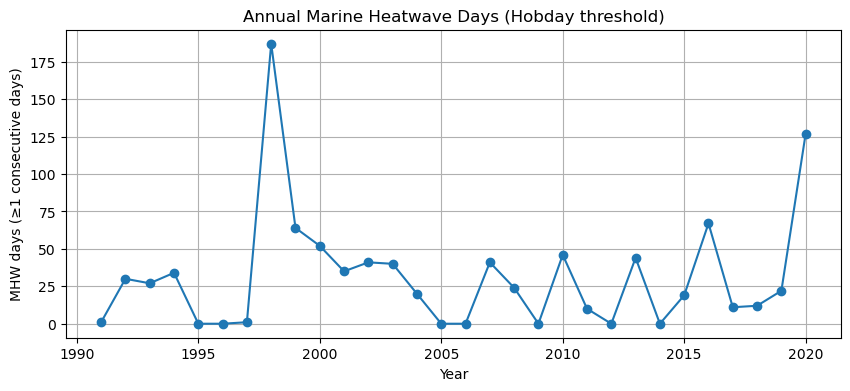

In [640]:
#Hobday法で定義した海洋熱波が、年ごとにどれだけ起きたか
events_5days['year'] = events_5days['start_date'].dt.year

mhw_days_per_year = events_5days.groupby('year')['duration'].sum()
years = np.arange(1991, 2021)

mhwdays = (
    mhw_days_per_year
    .reindex(years)      # 年配列に合わせる
    .fillna(0)           # 無い年は 0
    .to_numpy()
)


import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(years, mhwdays, marker='o')
plt.xlabel('Year')
plt.ylabel('MHW days (≥1 consecutive days)')
plt.title('Annual Marine Heatwave Days (Hobday threshold)')
plt.grid(True)
plt.show()

In [641]:
mhw_days_per_year.values

array([  1,  30,  27,  34,   1, 187,  64,  52,  35,  41,  40,  20,  41,
        24,  46,  10,  44,  19,  67,  11,  12,  22, 127], dtype=int64)

In [642]:
mhw_days_per_year.index

Index([1991, 1992, 1993, 1994, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004,
       2007, 2008, 2010, 2011, 2013, 2015, 2016, 2017, 2018, 2019, 2020],
      dtype='int32', name='year')

In [643]:
#date:観測日　Temp.:その日の実測水温　climatology:その日の平年水温　threshold:その日の90％しきい値
#is_hot:Temp. > thresholdならTrue　intensity = Temp.-climatology
# しきい値がちゃんと付いているか
df_mhw[['date','Temp.','climatology','threshold','is_hot']].head()

# 抽出されたイベントの先頭
events_5days.head()

,start_date,end_date,duration,max_temp,mean_temp,max_intensity,mean_intensity,year
0,1991-07-22,1991-07-22,1,28.40,28.400000,1.182515,1.182515,1991
1,1992-03-05,1992-03-19,15,19.08,19.024000,0.943970,0.872422,1992
2,1992-03-23,1992-03-29,7,19.64,19.454286,1.143848,0.990701,1992
3,1992-04-05,1992-04-12,8,20.19,20.038750,1.106394,0.981284,1992
4,1993-01-12,1993-01-19,8,20.36,20.128750,1.356727,1.139712,1993


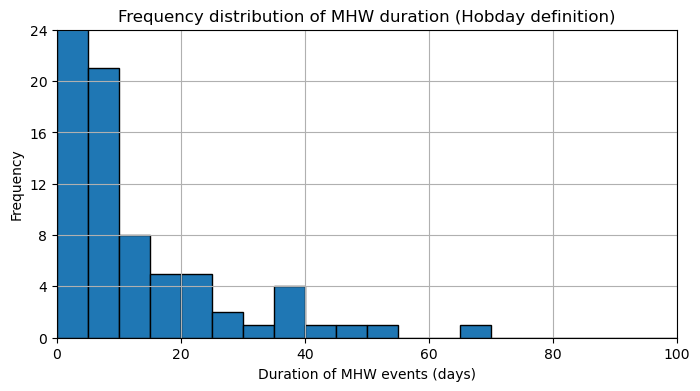

In [644]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.grid(True)
plt.hist(events_5days['duration'], bins=np.arange(0, 101, 5), edgecolor='black')
plt.xlim(0, 100)
plt.ylim(0, 24)
plt.yticks(np.linspace(0, 24, 7))
plt.xlabel('Duration of MHW events (days)')
plt.ylabel('Frequency')
plt.title('Frequency distribution of MHW duration (Hobday definition)')
plt.show()

In [645]:
duration_counts = events_5days['duration'].value_counts().sort_index()
duration_counts

duration
1      8
2      6
3      3
4     10
6      7
7      5
8      4
9      5
10     2
11     1
12     1
13     2
14     2
15     2
16     1
17     1
19     1
21     2
23     2
24     1
25     2
33     1
35     1
36     1
39     2
42     1
48     1
51     1
68     1
Name: count, dtype: int64

(array([27., 12., 12.,  5.,  4.,  3.,  3.,  2.,  0.,  1.,  2.,  2.,  1.,
         0.,  2.,  0.,  0.,  0.,  0.,  1.]),
 array([ 1.  ,  4.35,  7.7 , 11.05, 14.4 , 17.75, 21.1 , 24.45, 27.8 ,
        31.15, 34.5 , 37.85, 41.2 , 44.55, 47.9 , 51.25, 54.6 , 57.95,
        61.3 , 64.65, 68.  ]),
 <BarContainer object of 20 artists>)

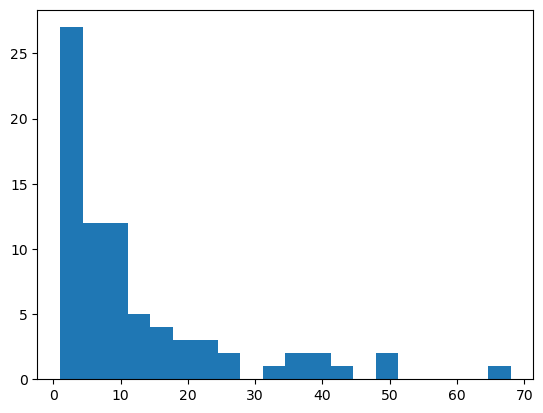

In [646]:
plt.hist(events_5days['duration'], bins=20)

In [647]:
very_long = events_5days[
    (events_5days['duration'] >= 60) &
    (events_5days['duration'] <= 80)
]

very_long

,start_date,end_date,duration,max_temp,mean_temp,max_intensity,mean_intensity,year
15,1998-04-01,1998-06-07,68,24.59,22.795147,3.345424,2.273303,1998


In [648]:
very_long = events_5days[
    (events_5days['duration'] >= 120) &
    (events_5days['duration'] <= 140)
]

very_long

,start_date,end_date,duration,max_temp,mean_temp,max_intensity,mean_intensity,year


In [649]:
# まず df_mhw がある前提
df_mhw['year'] = df_mhw['date'].dt.year

In [650]:
# 2025年を除外（途中の年を抜く）
df_mhw_no2025 = df_mhw[df_mhw['year'] < 2025].copy()

In [651]:
# その年に is_hot=True だった日数（暦年ベース）
mhw_days_per_year_true = (
    df_mhw_no2025[df_mhw_no2025['is_hot']]
    .groupby('year')
    .size()
)

In [652]:
# 2024 年だけ取り出す
mhw_2024 = mhw_days_per_year_true.loc[2024] if 2024 in mhw_days_per_year_true.index else 0
print("2024年の MHW日数（暦年ベース）:", mhw_2024)

2024年の MHW日数（暦年ベース）: 0


In [653]:
# 全体の年別
print(mhw_days_per_year_true)

year
1991      1
1992     30
1993     27
1994     25
1995      9
1997      1
1998    159
1999     92
2000     52
2001     35
2002     41
2003     40
2004     20
2007     41
2008     24
2010     46
2011     10
2013     44
2015     19
2016     67
2017     11
2018     12
2019     22
2020    127
dtype: int64


In [654]:
#df = pd.read_csv('area310.txt', skipfooter=1, engine='python') 

In [655]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [656]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [657]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

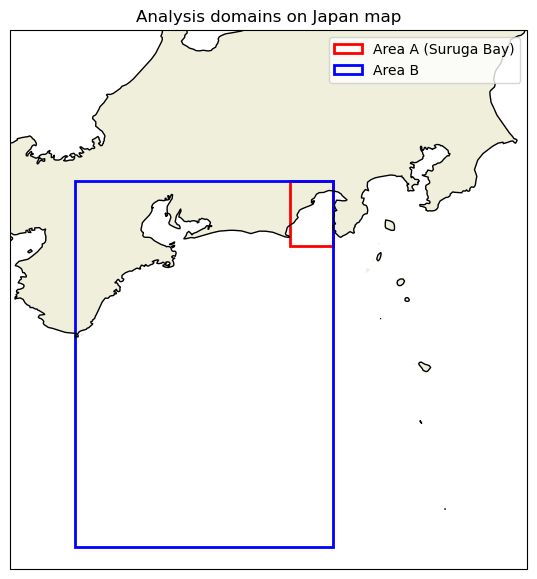

In [658]:
areas = [
    dict(name="Area A (Suruga Bay)",
         lat_min=34.5, lat_max=35.25, lon_min=138.25, lon_max=138.75,
         color="red"),
    #dict(name="Area C",
         #lat_min=33.0, lat_max=35.25, lon_min=137.0, lon_max=138.75,
         #color="blue"),
    dict(name="Area B",
         lat_min=31.0, lat_max=35.25, lon_min=135.75, lon_max=138.75,
         color="blue"),
]

fig = plt.figure(figsize=(7,7))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([135, 141, 30.75, 37], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')

for a in areas:
    rect = patches.Rectangle(
        (a["lon_min"], a["lat_min"]),
        a["lon_max"] - a["lon_min"],
        a["lat_max"] - a["lat_min"],
        fill=False,
        linewidth=2,
        edgecolor=a["color"],
        transform=ccrs.PlateCarree(),
        label=a["name"]
    )
    ax.add_patch(rect)

ax.set_title("Analysis domains on Japan map")
plt.legend()
plt.show()

In [659]:
print(out.columns)

Index(['Area A (Suruga Bay)', 'Area B'], dtype='object')


In [660]:
import os
import numpy as np
import pandas as pd
import netCDF4

# ここはあなたの設定を使う
# nc_dir = "MGDSST"
# fname_pat = "mgdsst_jpn.{year}.nc"
# ybgn, yend = 1991, 2020
# areas = [...]  ← すでに定義済み
FILL = -9.99e33

def area_annual_mean_from_nc(nc_path, box):
    """1年ファイル（mgdsst_jpn.YYYY.nc）から、指定boxの年平均SSTを返す"""
    with netCDF4.Dataset(nc_path, "r") as nc:
        tos = nc.variables["tos"][:]   # (time, lat, lon)
        lat = nc.variables["lat"][:]
        lon = nc.variables["lon"][:]

        fill = getattr(nc.variables["tos"], "_FillValue", FILL)

    lat_idx = np.where((lat >= box["lat_min"]) & (lat <= box["lat_max"]))[0]
    lon_idx = np.where((lon >= box["lon_min"]) & (lon <= box["lon_max"]))[0]
    if len(lat_idx) == 0 or len(lon_idx) == 0:
        return np.nan

    tos = np.array(tos, dtype=float)
    tos[tos <= -9.99e32] = np.nan
    tos[tos == fill] = np.nan

    sub = tos[:, lat_idx[:, None], lon_idx]     # (time, nlat, nlon)
    daily_area_mean = np.nanmean(sub, axis=(1, 2))
    return float(np.nanmean(daily_area_mean))    # 年平均（1値）

# ---- out を作り直す ----
years = np.arange(ybgn, yend + 1)
out = pd.DataFrame(index=years)

for box in areas:
    vals = []
    for y in years:
        fn = os.path.join(nc_dir, fname_pat.format(year=y))
        vals.append(area_annual_mean_from_nc(fn, box))
    out[box["name"]] = vals

out.index.name = "year"

print("out shape:", out.shape)
print(out.columns)
print(out.head())

out shape: (30, 2)
Index(['Area A (Suruga Bay)', 'Area B'], dtype='object')
      Area A (Suruga Bay)     Area B
year                                
1991            20.151233  22.243032
1992            20.673279  22.291803
1993            20.258740  22.139393
1994            21.015069  22.827718
1995            20.555014  22.581951


In [661]:
print(out.columns)

Index(['Area A (Suruga Bay)', 'Area B'], dtype='object')


In [666]:
from scipy.signal import detrend

# anomaly（各列から平均との差）
df_anom = out - out.mean()

# detrend（各列のトレンド除去）
df_dt = df_anom.apply(detrend)

# 相関行列
corr = df_dt.corr()
print(corr)

                     Area A (Suruga Bay)    Area B
Area A (Suruga Bay)             1.000000  0.865918
Area B                          0.865918  1.000000


In [667]:
from scipy.signal import detrend

df_anom = out - out.mean()
df_dt = df_anom.apply(detrend)

labels = df_dt.columns.tolist()

IndexError: single positional indexer is out-of-bounds

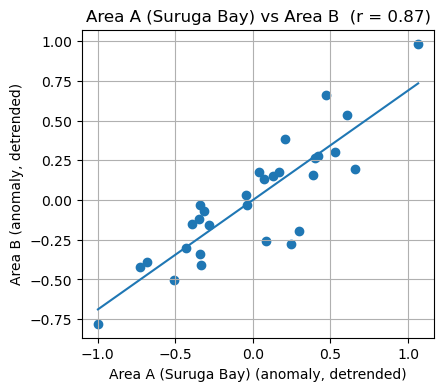

In [668]:
import matplotlib.pyplot as plt
import numpy as np

labels = df_dt.columns.tolist()

# A–B と A–C
pairs = [
    (0, 1),  # A–B
    (0, 2),  # A–C
]

plt.figure(figsize=(10, 4))  # ← 横長

for k, (i, j) in enumerate(pairs, start=1):
    x = df_dt.iloc[:, i].values
    y = df_dt.iloc[:, j].values

    # 相関
    r = np.corrcoef(x, y)[0, 1]

    # 回帰直線
    a, b = np.polyfit(x, y, 1)
    xx = np.linspace(x.min(), x.max(), 100)

    plt.subplot(1, 2, k)
    plt.scatter(x, y)
    plt.plot(xx, a*xx + b)

    plt.xlabel(labels[i] + " (anomaly, detrended)")
    plt.ylabel(labels[j] + " (anomaly, detrended)")
    plt.title(f"{labels[i]} vs {labels[j]}  (r = {r:.2f})")
    plt.grid(True)

plt.tight_layout()
plt.show()
